# Compares stats

In [1]:
%run load-rds-final-2012-23903000-rs.ipynb

Welcome to JupyROOT 6.28/00


Loaded rdf with 305828 enries


In [2]:
def mygroupby(d, groupbycols):
    g = d.groupby(groupbycols).size().reset_index(name='count').sort_values([ 'count'], ascending=False).reset_index(drop=True)
    g["Percentage"] = g.apply(lambda row: 100 * row["count"]/d.shape[0], axis=1)
    g["cumulative %"] = g["Percentage"].cumsum(axis = 0)
    return g

In [3]:
import categories4 as f
rdf_initial = rdf
rdf = f.add_categories_and_filter(rdf_initial,  apply_BDT_Iso_cut=True, apply_PIDK_cut=True)

In [4]:
base_columns = [ "eventIndex", "category", "simplified", "B_M", "B_Y_SEP", "Xc_signal_Ypis_displaced_fromBs_fromTau", "fromY_from_B_vertex", "BDT_Iso", "q2_2", "tauY_2"]
load_columns = [
    "Y_0_40_nc_mult",
    "Y_0_20_cc_mult",
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
#     "log(abs(PBsn))",
#     "log(abs(PBv/B_P))",
#     "log(abs(PBvn/B_P))",
#     "log(abs((PBsn-PBvn)/PBvn))",
#     "log(sqrt(abs(mDs2vn)))",
    "mN2v",
#    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
    'PBsn',
    'PBv', 'PBvn', 'B_P', 'mDs2vn', 'Y_PE'
]
train_columns = [
    "Y_0_40_nc_mult",
    "Y_0_20_cc_mult",
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
    "log(abs(PBsn))",
    "log(abs(PBv/B_P))",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "mN2v",
    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]

columns = base_columns +  load_columns
df = pd.DataFrame(rdf.Cache(columns).AsNumpy())


In [5]:
df['simplified_key'] = df.apply(lambda row: f.pretty_categories_map[row["simplified"]], axis=1)
df['key'] = df.apply(lambda row: f.categories_map[row["category"]], axis=1)
df['signal'] = (df['simplified_key'] == 'Signal')
dfbm = df.query("B_M < 5000")

In [124]:
df.query("B_M < 5000").query("signal == True").query("q2_2 > 0")

,BDT_Iso,B_BPVVDR,B_M,B_P,B_Y_SEP,B_correctedMass,B_pT_Bdir,PBsn,PBv,PBvn,...,max_m2pi,min_m2pi,missing_mass_2,missing_pY_mass,q2_2,simplified,tauY_2,simplified_key,key,signal
18,0.300701,1.251786,3555.436260,73440.504631,-5.396421,4648.655407,964.673579,95030.086006,119258.329865,102598.838899,...,717.463194,326.297603,634.665738,-309.581326,7.492151,1007,0.000324,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
27,0.304464,2.207561,4295.377515,161397.486742,-13.755033,4867.665362,538.646115,218321.801510,227549.612874,218321.949795,...,1136.189727,631.568058,341.499885,317.509062,4.852885,1007,0.000512,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
191,0.399764,3.409034,4101.212991,144294.265574,-29.192873,5547.156730,1257.491041,123290.341564,132639.509066,130663.716106,...,711.771211,547.652312,-1185.865988,536.725748,7.190575,1007,0.000946,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
192,0.060515,1.316995,4603.941355,152274.692578,-17.808110,5027.680017,405.882071,148826.309470,151727.047076,148868.065327,...,873.148779,786.979971,-356.337971,396.317398,5.524680,1007,0.000726,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
274,0.316373,1.963349,4468.346674,191079.648151,-6.288015,5286.581659,754.913492,161847.575966,179169.819382,161867.100541,...,721.087590,655.613555,-754.646648,517.683761,6.000162,1007,0.000149,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242268,0.235340,1.554001,3972.670890,207990.577214,-7.814765,5305.832564,1165.674289,292365.048373,351147.073467,316351.741998,...,932.845543,836.936942,-971.323028,486.019541,3.913299,1007,0.000234,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
242374,0.430140,6.910549,3387.932555,77325.281992,-23.642952,3737.534285,333.251195,81476.991060,88985.847274,81830.132992,...,595.212368,570.175348,852.768024,838.358234,8.128510,1007,0.000633,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
242395,0.198366,2.908379,3819.010212,90789.831007,-7.146156,4266.577350,424.092075,107943.957038,116331.299456,107979.802988,...,891.375999,764.576723,758.678435,529.004453,6.473756,1007,0.000470,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
242476,0.229566,1.213361,4300.833408,145979.948903,-8.153945,5283.667754,891.424042,127477.921173,131290.652600,127653.882759,...,759.718200,435.177340,-815.592170,463.230325,7.859131,1007,0.000334,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True


In [12]:
dfbm.query("BDT_Iso <  0.03458")

,BDT_Iso,B_BPVVDR,B_M,B_P,B_Y_SEP,B_correctedMass,B_pT_Bdir,PBsn,PBv,PBvn,...,max_m2pi,min_m2pi,missing_mass_2,missing_pY_mass,q2_2,simplified,tauY_2,simplified_key,key,signal


THIS INCLUDES THE CUT q2_2 > 0 BY DEFAULT

In [17]:
print(categ_after_bysep_cut[['count', 'Percentage', 'cut efficiency']].to_latex(float_format="%.3f" ))

\begin{tabular}{lrrr}
\toprule
{} &   count &  Percentage &  cut efficiency \\
Category           &         &             &                 \\
\midrule
Double Charm       &  204311 &      87.646 &           0.964 \\
Bad Xc             &   20449 &       8.772 &           0.953 \\
Signal             &    3562 &       1.528 &           0.999 \\
Normalization like &    2034 &       0.873 &           0.745 \\
Combinatorial      &    1433 &       0.615 &           0.812 \\
Tau from charm     &    1110 &       0.476 &           0.997 \\
Other displaced    &     163 &       0.070 &           0.916 \\
others             &      48 &       0.021 &           1.000 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_332790/1900856644.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(categ_after_bysep_cut[['count', 'Percentage', 'cut efficiency']].to_latex(float_format="%.3f" ))


In [125]:
import joblib
bdtdblcharm = joblib.load("../../train_bdt/bdtdblcharm_150_3_0.04.pkl")
def add_cols_for_bdt(tmpdf):
    df = tmpdf.copy()
    df["log(abs(PBsn))"] = np.log(np.abs(df["PBsn"]))
    df["log(abs(PBv/B_P))"] = np.log(np.abs(df["PBv"] / df["B_P"]))
    df["log(abs(PBvn/B_P))"] = np.log(np.abs(df["PBvn"] / df["B_P"]))
    df["log(abs((PBsn-PBvn)/PBvn))"] = np.log(np.abs((df["PBsn"] - df["PBvn"]) / df["PBvn"]))
    df["log(sqrt(abs(mDs2vn)))"] = np.log(np.sqrt(np.abs(df["mDs2vn"])))
    df["log(Y_PE)"] = np.log(df["Y_PE"]) 
    df["diff_m2pi"] = df["max_m2pi"] - df["min_m2pi"]
    return df
dfbm2 = add_cols_for_bdt(dfbm)

In [126]:
dfbm2['bdt_dc'] = bdtdblcharm.predict_proba(dfbm2[train_columns])[:,1]

In [127]:
dfbm2.to_hdf('data_with_bdt_dc.h5', key='df', mode='w')

/tmp/ipykernel_332790/2196017620.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['Xc_signal_Ypis_displaced_fromBs_fromTau', 'fromY_from_B_vertex',
       'simplified_key', 'key'],
      dtype='object')]

  dfbm2.to_hdf('data_with_bdt_dc.h5', key='df', mode='w')


In [134]:
dfbm2.query("signal == True")['category'].unique()

array([24, 10, 11], dtype=int32)

In [135]:
f.categories_map

{0: 'Xc_background',
 1: 'Xc_signal_Ypis_diffAncestorYXc',
 2: 'Xc_signal_Ypis_B_vertex_fromBs',
 3: 'Xc_signal_Ypis_B_vertex_fromOtherB',
 4: 'Xc_signal_Ypis_B_vertex_fromHc',
 5: 'Xc_signal_Ypis_B_vertex_fromNone',
 6: 'Xc_signal_Ypis_nomatch_Prompt',
 7: 'Xc_signal_Ypis_nomatch_doubleCharm',
 8: 'Xc_signal_Ypis_nomatch_charmStrange',
 9: 'Xc_signal_Ypis_nomatch_Other',
 10: 'Xc_signal_Ypis_diffVertex_signal',
 11: 'Xc_signal_Ypis_diffVertex_tauFromB',
 12: 'Xc_signal_Ypis_diffVertex_normlike',
 13: 'Xc_signal_Ypis_diffVertex_doubleCharm',
 14: 'Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB',
 15: 'Xc_signal_Ypis_diffVertex_doubleCharm_TwoFromB',
 16: 'Xc_signal_Ypis_diffVertex_CharmStrange',
 17: 'Xc_signal_Ypis_diffVertex_SomeFromPV',
 18: 'Xc_signal_Ypis_displaced_fromBs_fromDs',
 19: 'Xc_signal_Ypis_displaced_fromB0_fromDp',
 20: 'Xc_signal_Ypis_displaced_fromBp_fromD0',
 21: 'Xc_signal_Ypis_displaced_fromLambdab_fromLambdac',
 22: 'Xc_signal_Ypis_displaced_fromBs_fromDp',
 23: 

In [111]:
dfbm2

,BDT_Iso,B_BPVVDR,B_M,B_P,B_Y_SEP,B_correctedMass,B_pT_Bdir,PBsn,PBv,PBvn,...,log(abs(PBsn)),log(abs(PBv/B_P)),log(abs(PBvn/B_P)),log(abs((PBsn-PBvn)/PBvn)),log(sqrt(abs(mDs2vn))),log(Y_PE),diff_m2pi,bdt_dc,group1_category,group1_name
0,0.142126,5.122865,3549.868167,168977.117807,-42.580564,4429.095708,791.959042,213931.912377,227255.066624,224798.696179,...,12.273413,0.296310,0.285442,-3.029495,7.911052,10.883605,414.693391,0.480915,4,"diffVertex_doubleCharm_TwoFromB, Xc_background, others"
1,0.084323,1.668125,3319.233948,61299.597437,-25.553933,3650.446180,316.186461,68422.978613,75375.247132,68627.893311,...,11.133464,0.206706,0.112926,-5.813861,7.786525,9.734375,197.234971,0.047678,4,"diffVertex_doubleCharm_TwoFromB, Xc_background, others"
2,0.368573,1.993594,3952.608126,156837.935763,-10.530797,4331.339197,362.173002,193830.018453,206759.162365,194002.880756,...,12.174737,0.276342,0.212660,-7.023133,7.734093,11.047794,35.228538,0.550376,6,"displaced_fromB0_fromD0, nomatch_doubleCharm, displaced_fromB0_fromDp, diffVertex_doubleCharm"
3,0.152137,0.780185,3590.944305,86795.626730,-5.040866,4689.721792,970.058554,63525.280784,74187.153322,64659.427607,...,11.059193,-0.156965,-0.294422,-4.043253,7.936118,10.755483,143.757553,0.744786,4,"diffVertex_doubleCharm_TwoFromB, Xc_background, others"
4,0.382045,1.299142,3747.756129,148853.385470,-5.497857,4000.589420,244.843884,152223.181078,163115.939253,152258.133512,...,11.933103,0.091499,0.022615,-8.379345,7.086510,9.932745,56.547468,0.057617,0,displaced_fromBs_fromDs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242735,0.321024,4.012284,4027.889398,202833.051607,-20.939083,5027.599310,900.316559,278687.778202,301173.947829,286704.281254,...,12.537847,0.395305,0.346068,-3.576949,7.392935,11.387447,558.693289,0.197994,0,displaced_fromBs_fromDs
242736,0.132013,0.912369,4565.097589,171913.729033,-12.364674,5011.791461,426.787276,169474.374381,172384.198847,169695.757786,...,12.040457,0.002733,-0.012986,-6.641866,7.637914,10.947215,93.671025,0.435207,0,displaced_fromBs_fromDs
242737,0.340379,1.283536,4689.555203,142928.520106,-29.903899,6174.122483,1306.085235,123794.055575,126366.400090,123879.637927,...,11.726375,-0.123159,-0.143034,-7.277587,7.654822,10.930162,275.300333,0.302139,0,displaced_fromBs_fromDs
242738,0.266166,1.156650,3400.800053,108148.088194,-5.197422,4531.720777,989.806372,145142.143730,176817.601762,145184.537346,...,11.885469,0.491617,0.294504,-8.138763,7.694428,10.076992,399.626947,0.345274,6,"displaced_fromB0_fromD0, nomatch_doubleCharm, displaced_fromB0_fromDp, diffVertex_doubleCharm"


# Loading the template

In [234]:
import yaml
from yaml import SafeLoader
# Loading the template configuration
with open("../config/templates.yaml") as yf:
    templates_config = yaml.load(yf, Loader=SafeLoader)

In [235]:
group1 = templates_config['templates']['group1']

In [185]:
print(group1)
group1_map = {}
group1_others = None
for i, c in enumerate(group1):
    if type(c) == int:
        group1_map[c] = i
    elif c == 'others':
        group1_others = i
    else:
        for cc in c:
            if cc == 'others':
                group1_others = i
            else:
                group1_map[cc] = i
print(group1_map)

def get_group1_categories(bkgcat):
    return group1[group1_map.get(bkgcat, group1_others)]

def _g1cat2name(cat):
    if type(cat) == int:
        tmp = f.categories_map[cat]
        if tmp == "Xc_signal_Ypis_displaced_fromBs_fromTau":
            return "Signal"
        elif tmp in ['Xc_signal_Ypis_diffVertex_signal', 'Xc_signal_Ypis_diffVertex_tauFromB']:
            return None
        return tmp.replace("Xc_signal_Ypis_", "")
    elif cat == 'others':
        return 'others'
    elif type(cat) == list:
        #print(cat)
        catnames = [ _g1cat2name(c) for c in cat]
        #print(f"===> {catnames}")
        return ", ".join([cc for cc in catnames if cc is not None])
        #return ", ".join([cc for cc in catnames in cc is not None])
 

def _get_group1_name(c):
    #print(f"==>categ {c}")
    return _g1cat2name(group1[int(c)])


[18, 29, 23, [24, 10, 11], [15, 0, 'others'], [16, 14], [25, 7, 19, 13], [27, 22], 20, 26, 21]
{18: 0, 29: 1, 23: 2, 24: 3, 10: 3, 11: 3, 15: 4, 0: 4, 16: 5, 14: 5, 25: 6, 7: 6, 19: 6, 13: 6, 27: 7, 22: 7, 20: 8, 26: 9, 21: 10}


In [186]:
dfbm2['group1_category'] = dfbm2.apply(lambda row: group1_map.get(row['category'], group1_others), axis=1)
dfbm2['group1_name'] = dfbm2.apply(lambda row: _get_group1_name(row['group1_category']), axis=1)
#dfbm2



In [187]:
pd.set_option('display.max_colwidth', None)
stat_g1 = mygroupby(dfbm2, 'group1_name')
factor = 
stat_g1

,group1_name,count,Percentage,cumulative %
0,"displaced_fromB0_fromD0, nomatch_doubleCharm, displaced_fromB0_fromDp, diffVertex_doubleCharm",70747,30.349191,30.349191
1,displaced_fromBs_fromDs,47066,20.190468,50.539659
2,"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",38616,16.565570,67.105229
3,"diffVertex_doubleCharm_TwoFromB, Xc_background, others",27492,11.793574,78.898803
4,displaced_fromBp_fromD0,18506,7.938741,86.837545
5,"displaced_fromBs_fromD0, displaced_fromBs_fromDp",11752,5.041397,91.878941
6,displaced_fromLambdab_fromLambdac,6433,2.759641,94.638583
7,displaced_fromBp_fromDp,5843,2.506542,97.145125
8,Signal,3562,1.528034,98.673159
9,displaced_fromB0_fromDs,2108,0.904294,99.577453


# Correlations between the variables for each group

In [188]:
dfbm2[['q2_2', 'tauY_2', "bdt_dc", 'group1_name']].corr()

/tmp/ipykernel_332790/732302729.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  dfbm2[['q2_2', 'tauY_2', "bdt_dc", 'group1_name']].corr()


,q2_2,tauY_2,bdt_dc
q2_2,1.000000,0.000772,0.188696
tauY_2,0.000772,1.000000,-0.066909
bdt_dc,0.188696,-0.066909,1.000000


## Evaluating datasets after cuts

In [189]:
df_cut1 = dfbm2.query("bdt_dc >0.75")

In [225]:
stat_g1 = mygroupby(df_cut1, 'group1_name')
stat_g1.set_index('group1_name', inplace=True)
signal_count = int(232 * stat_g1.loc['Signal', 'count'] / 3562)
signal_percentage = stat_g1.loc['Signal', 'Percentage'] 
print(f"{signal_percentage} ==> {signal_count}")
ratio = signal_count / signal_percentage
stat_g1['yield_2invfb'] = stat_g1.apply(lambda row: int(row['Percentage'] * ratio), axis=1)
stat_g1['name'] = stat_g1.index
stat_g1['empty'] = ""

10.7387089501766 ==> 93


In [227]:
print(stat_g1[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))

\begin{tabular}{llrr}
\toprule
empty &                                                                                          name &  Percentage &  yield\_2invfb \\
      & displaced\_fromB0\_fromD0, nomatch\_doubleCharm, displaced\_fromB0\_fromDp, diffVertex\_doubleCharm &       30.39 &           263 \\
\midrule
      &                                        diffVertex\_doubleCharm\_TwoFromB, Xc\_background, others &       14.18 &           122 \\
      &                                              displaced\_fromBs\_fromD0, displaced\_fromBs\_fromDp &       13.38 &           115 \\
      &                                                                                        Signal &       10.74 &            93 \\
      &                                      diffVertex\_CharmStrange, diffVertex\_doubleCharm\_OneFromB &       10.43 &            90 \\
      &                                                                       displaced\_fromBs\_fromDs &        5.76 &            49

/tmp/ipykernel_332790/1193698796.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(stat_g1[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))


In [229]:
df_cut2 = dfbm2.query("bdt_dc >0.35")
stat_g2 = mygroupby(df_cut2, 'group1_name')
stat_g2.set_index('group1_name', inplace=True)
signal_count = int(232 * stat_g2.loc['Signal', 'count'] / 3562)
signal_percentage = stat_g2.loc['Signal', 'Percentage'] 
print(f"{signal_percentage} ==> {signal_count}")
ratio = signal_count / signal_percentage
stat_g2['yield_2invfb'] = stat_g2.apply(lambda row: int(row['Percentage'] * ratio), axis=1)
stat_g2['name'] = stat_g2.index
stat_g2['empty'] = ""
print(stat_g2[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))

3.3072859344045784 ==> 195
\begin{tabular}{llrr}
\toprule
empty &                                                                                          name &  Percentage &  yield\_2invfb \\
      & displaced\_fromB0\_fromD0, nomatch\_doubleCharm, displaced\_fromB0\_fromDp, diffVertex\_doubleCharm &       33.67 &          1985 \\
\midrule
      &                                      diffVertex\_CharmStrange, diffVertex\_doubleCharm\_OneFromB &       13.20 &           778 \\
      &                                                                       displaced\_fromBs\_fromDs &       13.03 &           768 \\
      &                                        diffVertex\_doubleCharm\_TwoFromB, Xc\_background, others &       12.40 &           731 \\
      &                                                                       displaced\_fromBp\_fromD0 &        8.26 &           487 \\
      &                                              displaced\_fromBs\_fromD0, displaced\_fromBs\_fromDp 

/tmp/ipykernel_332790/1195390536.py:11: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(stat_g2[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))


In [231]:
df_cut3 = dfbm2.query("bdt_dc >0.50")
stat_g3 = mygroupby(df_cut3, 'group1_name')
stat_g3.set_index('group1_name', inplace=True)
signal_count = int(232 * stat_g3.loc['Signal', 'count'] / 3562)
signal_percentage = stat_g3.loc['Signal', 'Percentage'] 
print(f"{signal_percentage} ==> {signal_count}")
ratio = signal_count / signal_percentage
stat_g3['yield_2invfb'] = stat_g3.apply(lambda row: int(row['Percentage'] * ratio), axis=1)
stat_g3['name'] = stat_g3.index
stat_g3['empty'] = ""
print(stat_g3[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))

4.811940741840864 ==> 168
\begin{tabular}{llrr}
\toprule
empty &                                                                                          name &  Percentage &  yield\_2invfb \\
      & displaced\_fromB0\_fromD0, nomatch\_doubleCharm, displaced\_fromB0\_fromDp, diffVertex\_doubleCharm &       33.48 &          1169 \\
\midrule
      &                                        diffVertex\_doubleCharm\_TwoFromB, Xc\_background, others &       12.94 &           451 \\
      &                                      diffVertex\_CharmStrange, diffVertex\_doubleCharm\_OneFromB &       12.79 &           446 \\
      &                                                                       displaced\_fromBs\_fromDs &       10.27 &           358 \\
      &                                              displaced\_fromBs\_fromD0, displaced\_fromBs\_fromDp &        9.31 &           325 \\
      &                                                                       displaced\_fromBp\_fromD0 &

/tmp/ipykernel_332790/104527034.py:11: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(stat_g3[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))


# CHecking the correlations within the group

In [113]:
group1

[18,
 29,
 23,
 24,
 [15, 0, 'others'],
 [16, 14],
 [25, 7, 19, 13],
 [27, 22],
 20,
 26,
 21]

In [232]:
all_others = [ c for c in dfbm2['category'].unique() if c not in group1_map ]
all_others
to_check = [] 
for i, g in enumerate(group1):
    if type(g) == list:
        print(g)

[24, 10, 11]
[15, 0, 'others']
[16, 14]
[25, 7, 19, 13]
[27, 22]


In [246]:
dfbm2.query("category == 15")[['q2_2', 'tauY_2', "bdt_dc"]].corr()

,q2_2,tauY_2,bdt_dc
q2_2,1.000000,-0.110613,0.139757
tauY_2,-0.110613,1.000000,-0.123434
bdt_dc,0.139757,-0.123434,1.000000


In [245]:
dfbm2.query("category == 0")[['q2_2', 'tauY_2', "bdt_dc"]].corr()

,q2_2,tauY_2,bdt_dc
q2_2,1.000000,-0.042752,0.216175
tauY_2,-0.042752,1.000000,-0.098170
bdt_dc,0.216175,-0.098170,1.000000


In [247]:
dfbm2.query("category == 27")[['q2_2', 'tauY_2', "bdt_dc"]].corr()

,q2_2,tauY_2,bdt_dc
q2_2,1.000000,-0.122684,0.080803
tauY_2,-0.122684,1.000000,-0.172539
bdt_dc,0.080803,-0.172539,1.000000


In [248]:
dfbm2.query("category == 22")[['q2_2', 'tauY_2', "bdt_dc"]].corr()

,q2_2,tauY_2,bdt_dc
q2_2,1.000000,-0.015733,0.172220
tauY_2,-0.015733,1.000000,-0.094319
bdt_dc,0.172220,-0.094319,1.000000


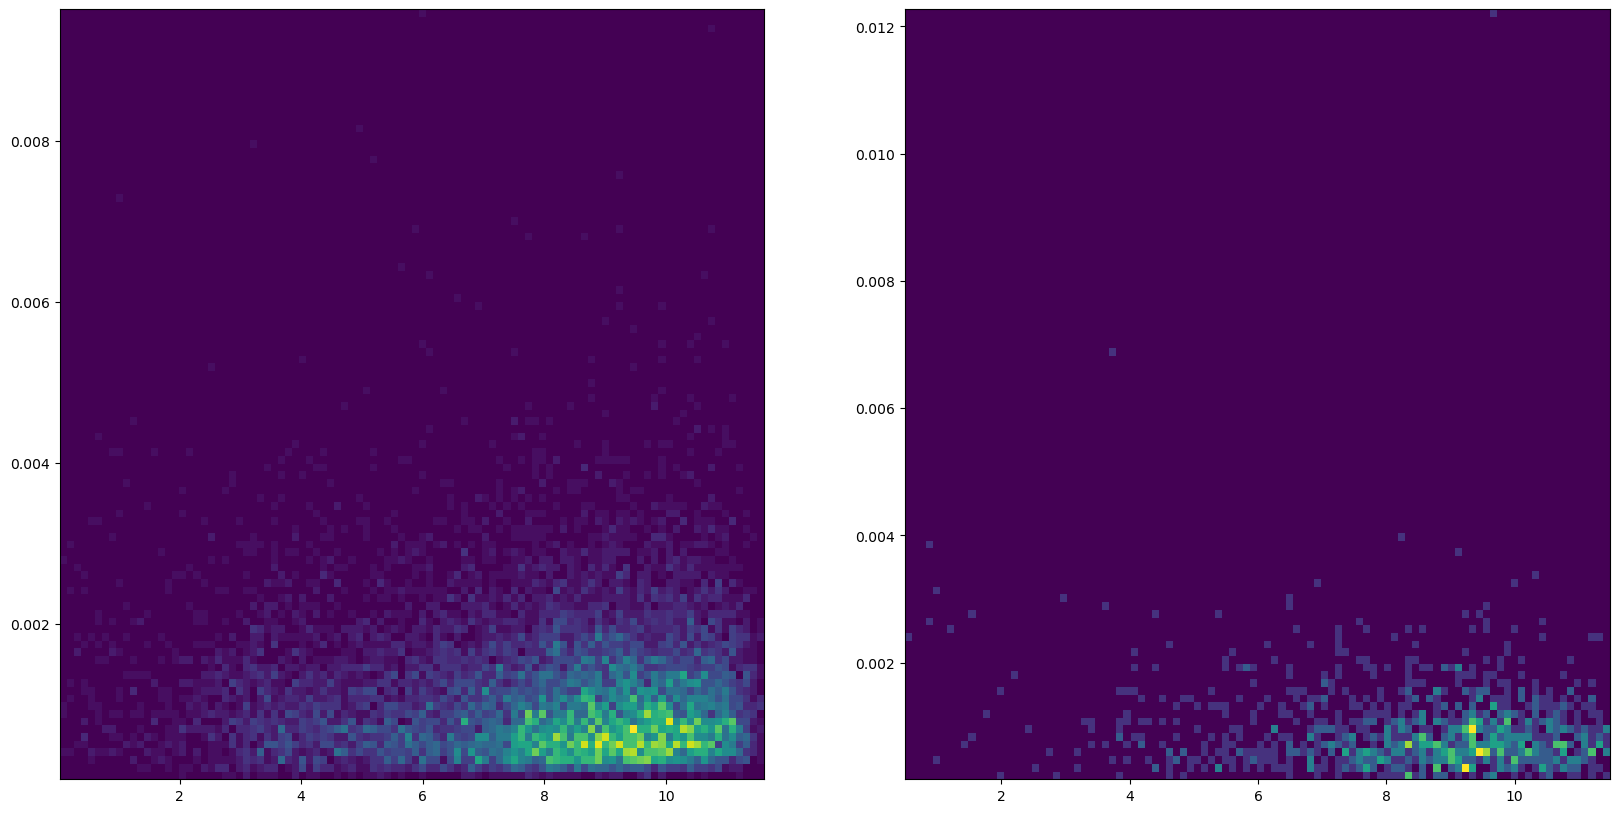

In [252]:
dftmp1 = dfbm2.query("category == 22")
dftmp2 = dfbm2.query("category == 27")
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist2d(dftmp1['q2_2'], dftmp1['tauY_2'], bins=100);
ax2.hist2d(dftmp2['q2_2'], dftmp2['tauY_2'], bins=100);

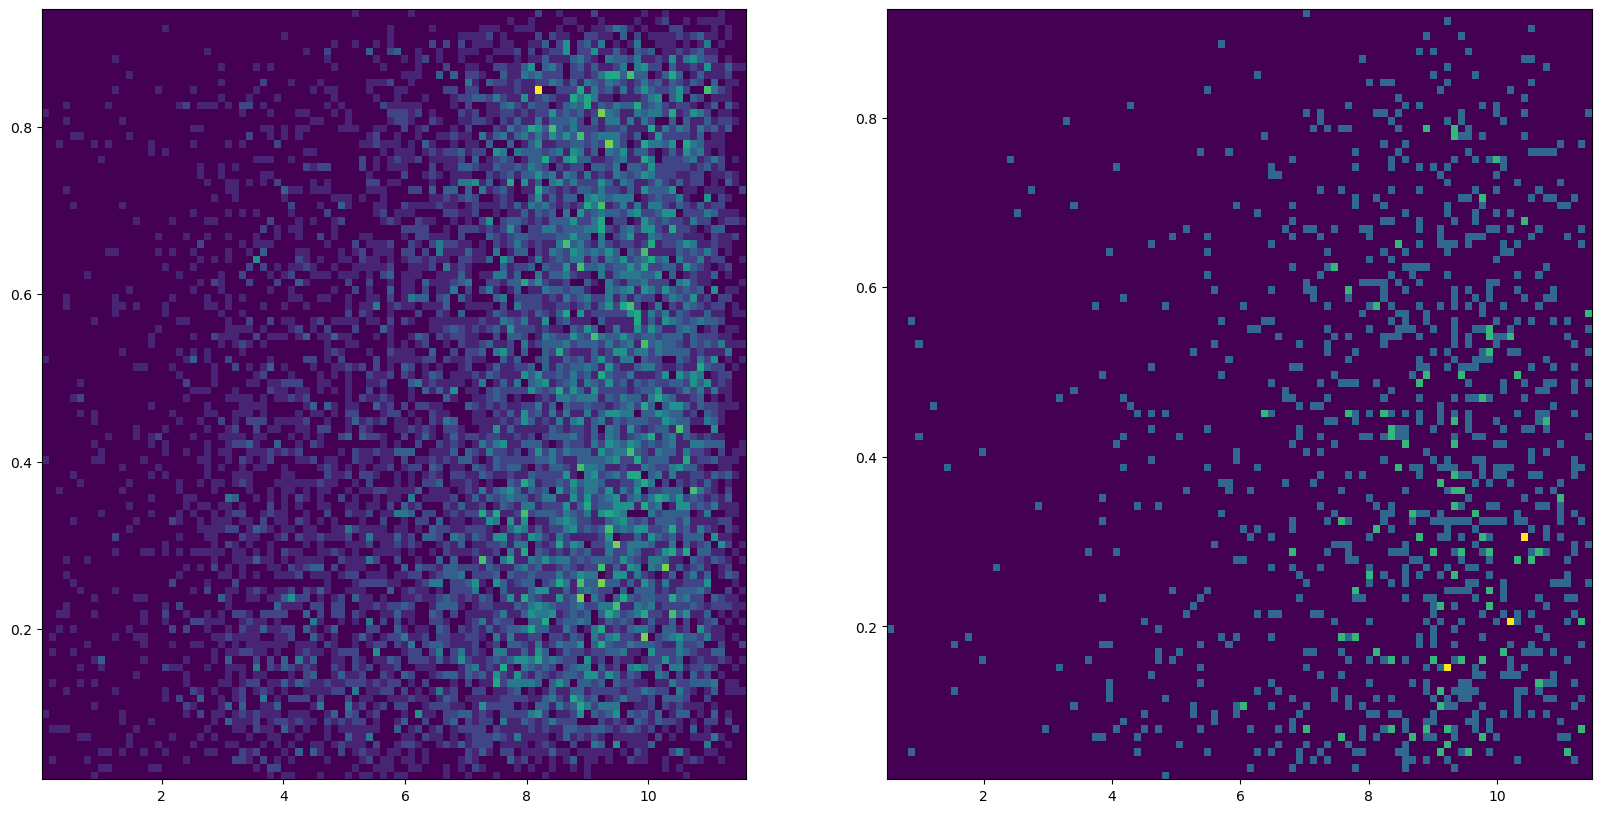

In [253]:
dftmp1 = dfbm2.query("category == 22")
dftmp2 = dfbm2.query("category == 27")
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist2d(dftmp1['q2_2'], dftmp1['bdt_dc'], bins=100);
ax2.hist2d(dftmp2['q2_2'], dftmp2['bdt_dc'], bins=100);

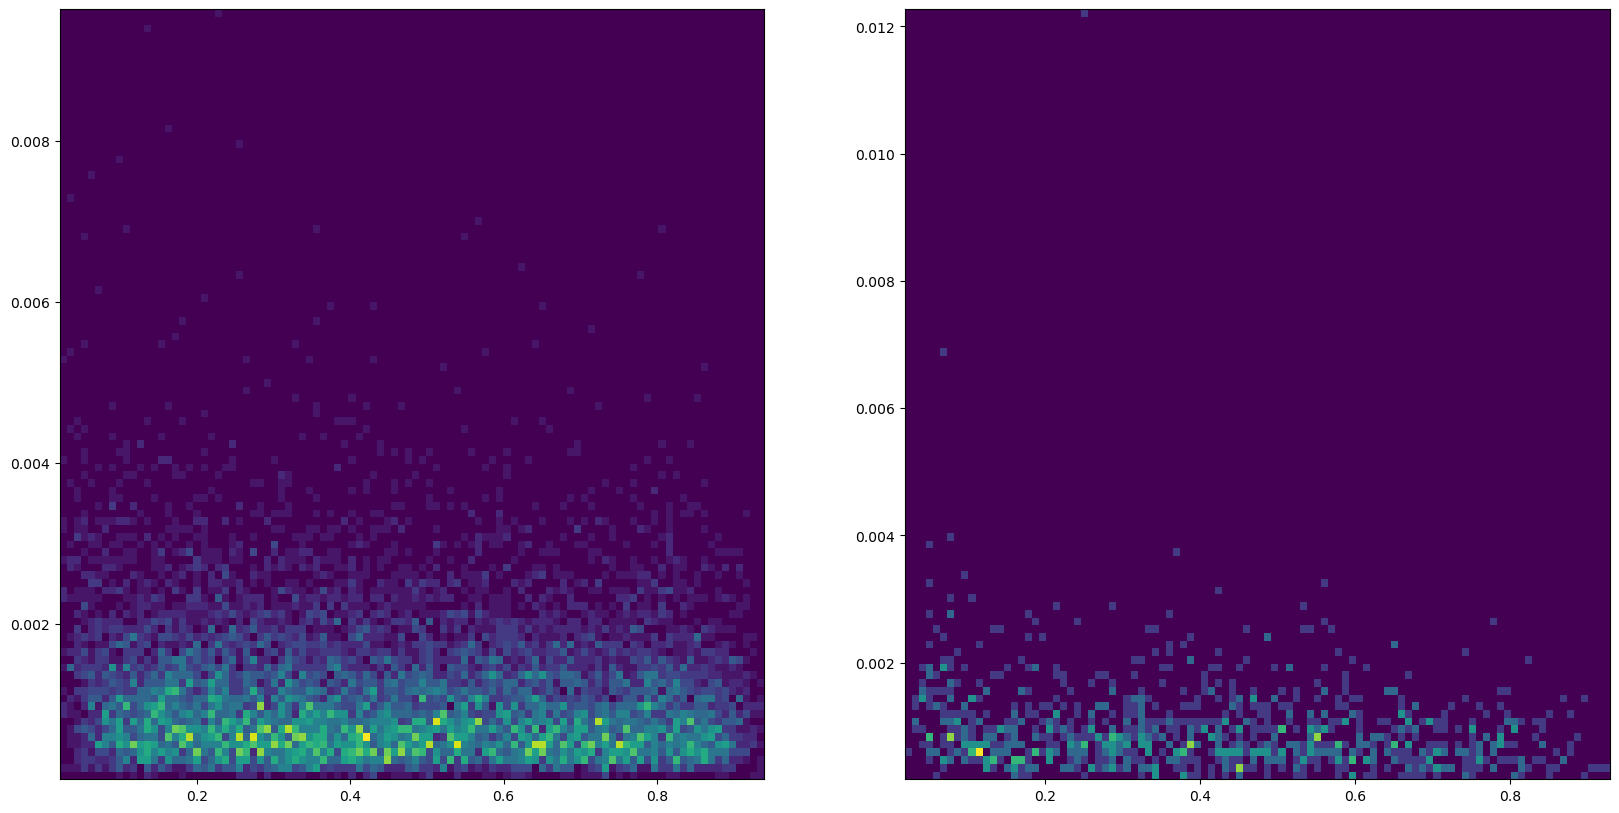

In [255]:
dftmp1 = dfbm2.query("category == 22")
dftmp2 = dfbm2.query("category == 27")
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist2d(dftmp1['bdt_dc'], dftmp1['tauY_2'], bins=100);
ax2.hist2d(dftmp2['bdt_dc'], dftmp2['tauY_2'], bins=100);